# Strong Scaling

This third experiment focus on the strong scaling.\
We fix $N$, vary $P$. Sample sort has $O(NlogN/P)$ local work and $O(N)$ aggregate communication; communication will dominate eventually. Find the cross-over for your machine.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 1. The number of **MPI ranks** increase exponentially from **4** to **256**. Here are reported the common configurations across all the runs:

* **n_bits** : $64$
* **n_keys** : $10^9$
* **n_threads** : $1$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [24]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [25]:
results = pd.read_csv("../Parallel/results/strong_scaling.csv")
results = results[
    [
        "n_bits",
        "n_key",
        "n_ranks",
        "n_threads",
        "time_communication_seconds",
        "time_total_seconds",
    ]
].sort_values("n_ranks")

results["comm_pct"] = (
    results["time_communication_seconds"] / results["time_total_seconds"]
) * 100

t4_strong = results.loc[results["n_ranks"] == 4, "time_total_seconds"].mean()
results["efficiency"] = (4*t4_strong / (results["time_total_seconds"] * results["n_ranks"])) * 100

ranks = results["n_ranks"].unique()
results.head()

,n_bits,n_key,n_ranks,n_threads,time_communication_seconds,time_total_seconds,comm_pct,efficiency
0,64,1000000000,4,1,3.768309,27.171625,13.868544,100.134726
7,64,1000000000,4,1,3.527788,27.369058,12.889694,99.412382
14,64,1000000000,4,1,3.531147,27.316242,12.926914,99.604597
21,64,1000000000,4,1,3.809515,26.976005,14.121865,100.860867
8,64,1000000000,8,1,2.853548,15.274156,18.682197,89.066241


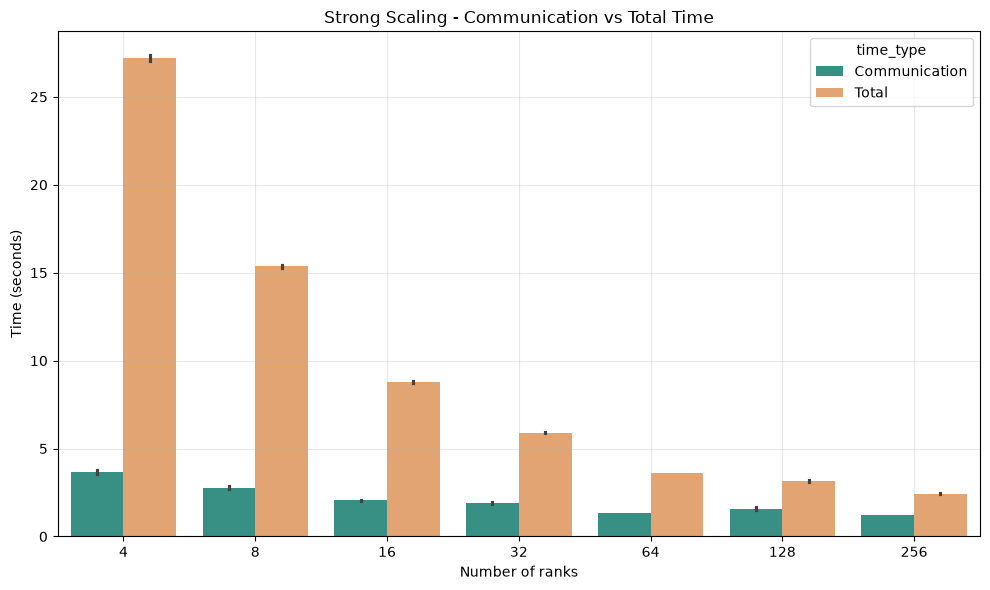

In [26]:
plot_data = results.melt(
    id_vars=["n_bits", "n_key", "n_ranks", "n_threads"],
    value_vars=[
        "time_communication_seconds",
        "time_total_seconds"
    ],
    var_name="time_type",
    value_name="time_seconds"
)

plot_data["time_type"] = plot_data["time_type"].map({
    "time_communication_seconds": "Communication",
    "time_total_seconds": "Total"
})

custom_palette = {
    "Communication" : "#2A9D8F",
    "Total" : "#F4A261"
}

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="n_ranks",
    y="time_seconds",
    hue="time_type",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Time (seconds)")
plt.title("Strong Scaling - Communication vs Total Time")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

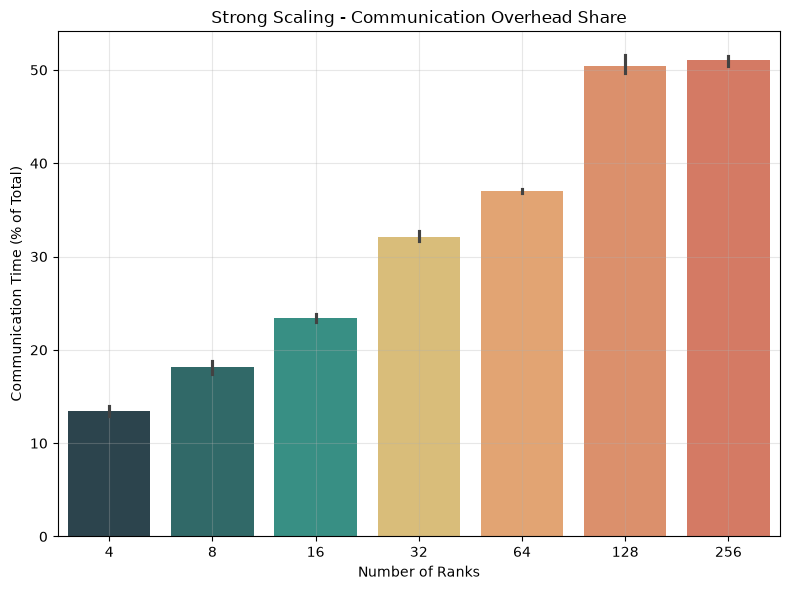

In [27]:
custom_palette_ranks = {
    4: "#264653",
    8: "#287271",
    16: "#2a9d8f",
    32: "#e9c46a",
    64: "#f4a261",
    128: "#ee8959",
    256: "#e76f51",
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="comm_pct",
    hue="n_ranks",
    palette=custom_palette_ranks,
    legend=False
)

plt.xlabel("Number of Ranks")
plt.ylabel("Communication Time (% of Total)")
plt.title("Strong Scaling - Communication Overhead Share")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

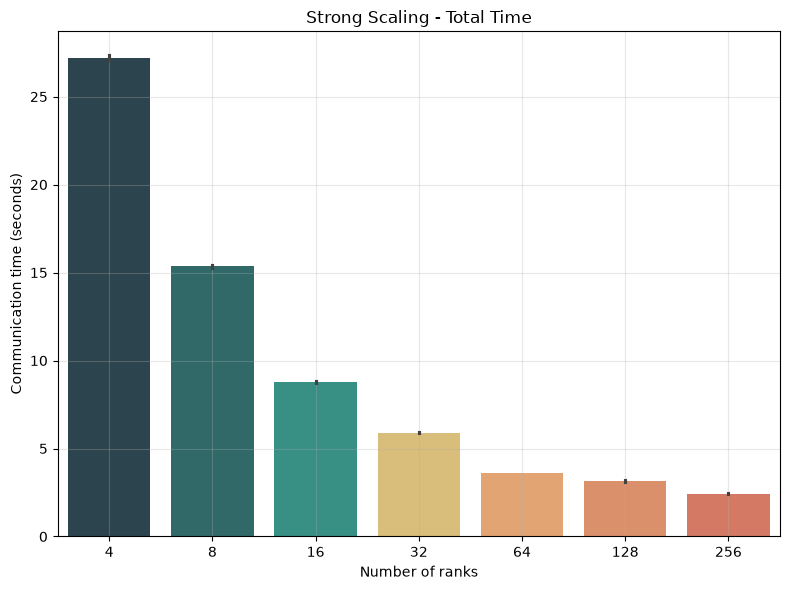

In [28]:
custom_palette = {
    4 :"#264653",
    8 : "#287271",
    16 : "#2a9d8f",
    32 : "#e9c46a",
    64 : "#f4a261",
    128 : "#ee8959",
    256 : "#e76f51",
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="n_ranks",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Number of ranks")
plt.ylabel("Communication time (seconds)")
plt.title("Strong Scaling - Total Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

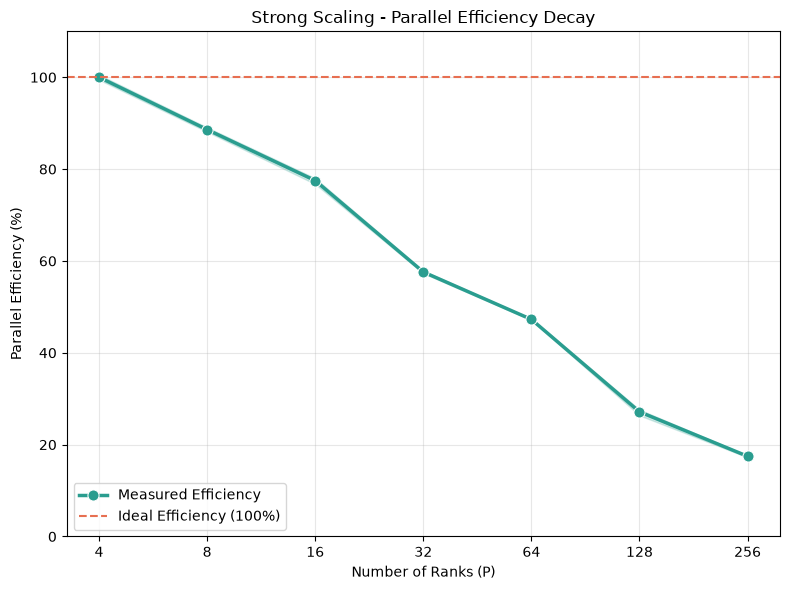

In [29]:
plt.figure(figsize=(8, 6))

# Plot measured strong efficiency curve using Seaborn
ax = sns.lineplot(
    data=results,
    x="n_ranks",
    y="efficiency",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#2A9D8F",
    label="Measured Efficiency",
)

# Reference ideal efficiency
plt.axhline(
    y=100,
    linestyle="--",
    color="#E76F51",
    linewidth=1.5,
    label="Ideal Efficiency (100%)",
)

plt.xscale("log", base=2)
ranks = sorted(results["n_ranks"].unique())
plt.xticks(ranks, ranks)

plt.xlabel("Number of Ranks (P)")
plt.ylabel("Parallel Efficiency (%)")
plt.title("Strong Scaling - Parallel Efficiency Decay")
plt.ylim(0, 110)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()